<a href="https://colab.research.google.com/github/muneer-ahmad10/Natural-Language-processing/blob/main/Day_26_RNN_LSTM_Transformer_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

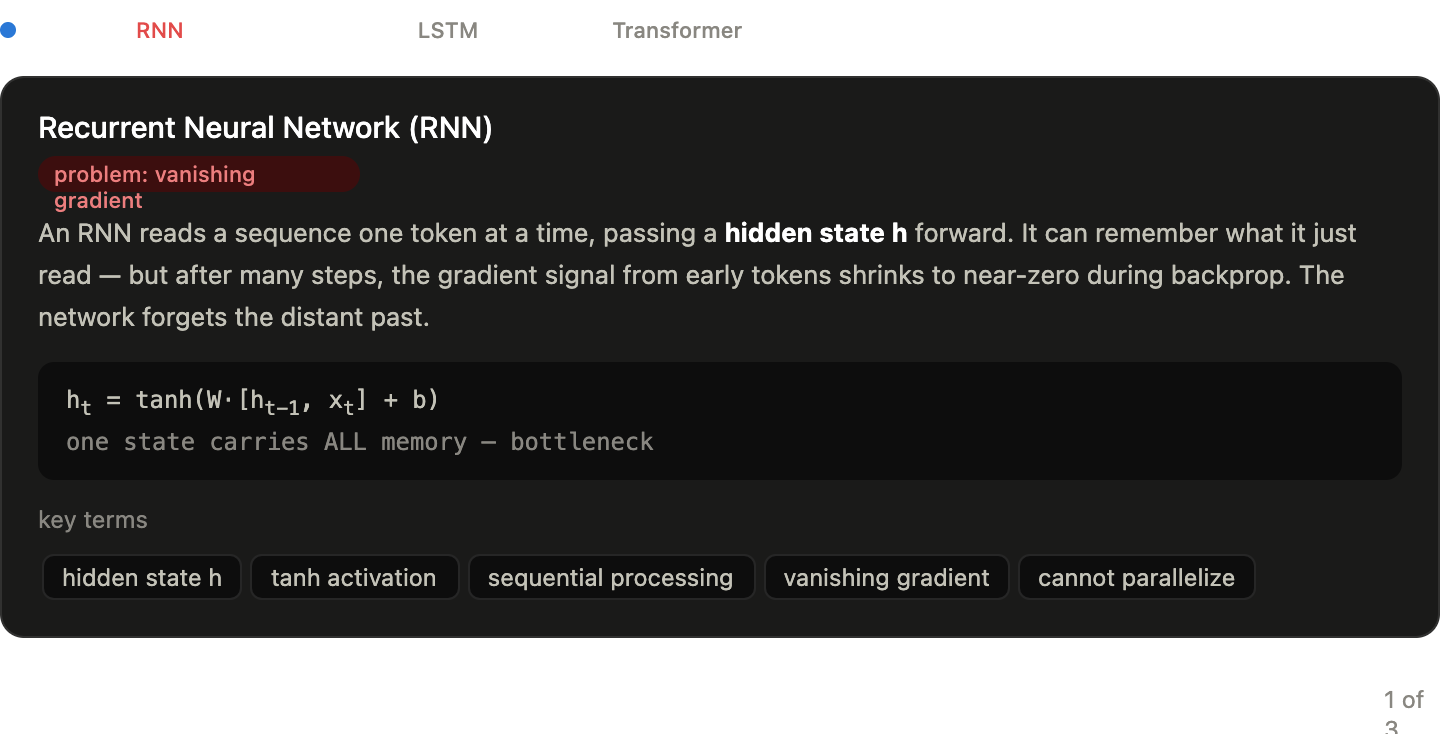

An RNN (Recurrent Neural Network) is designed to solve one massive problem that standard neural networks cannot handle: understanding sequences and memory.If a traditional neural network reads the sentence "I am flying to France, so I need to brush up on my ______," it treats every word completely independently. It doesn't remember that it read "France" by the time it reaches the blank line.An RNN fixes this by processing words one by one and passing a hidden state (memory) from one step to the next.1. How the RNN Engine Works (Step-by-Step)Instead of dumping the entire sentence into the network at once, the RNN loops through the text sequentially:Step 1: It reads the first word ("I"), creates a temporary memory of it, and passes that memory forward.Step 2: It reads the next word ("am"), combines it with the memory of "I", and creates an updated memory.Step 3: It reads "flying", combines it with the previous accumulated memory, and updates it again.This running memory is mathematically called the Hidden State ($h_t$).The Core FormulaFor your exam, you will likely see this exact equation:$$h_t = \tanh(W \cdot [h_{t-1}, x_t] + b)$$Let's demystify what these symbols actually mean:$x_t$: The current word vector you are looking at right now.$h_{t-1}$: The hidden state (memory) from the previous word.$W$ and $b$: The weights and biases the network learns.$\tanh$: An activation function that squashes the memory values strictly between -1 and 1 so the numbers don't explode to infinity as the sentence gets longer.2. The Fatal Flaw: Vanishing Gradient Problem 📉While the sequential loop sounds perfect in theory, traditional RNNs suffer from severe short-term memory loss.If your sentence is 50 words long, by the time the RNN reaches the 50th word, the mathematical signal from the 1st word has been multiplied by the weight matrix ($W$) 50 times over during backpropagation.If those weights are even slightly less than 1 (e.g., 0.9), multiplying 0.9 by itself 50 times makes the number shrink to near-zero.This is called the Vanishing Gradient Problem.The Result: The network completely forgets the beginning of long sentences. It cannot handle long-term dependencies.3. The 3 Mega Exam Traps for RNNs 🪤Professors love testing your understanding of RNN limitations. Watch out for these:Trap 1: "RNNs can be easily parallelized on GPUs." $\rightarrow$ FALSE.Because an RNN must compute the hidden state of word 2 before it can even look at word 3, you cannot process the words simultaneously. This makes training RNNs incredibly slow compared to Transformers (which process all words at once).Trap 2: "The hidden state size changes depending on the sentence length." $\rightarrow$ FALSE.The hidden state vector ($h$) has a fixed size (e.g., 128 or 256 dimensions) that you choose beforehand. That single vector acts as a bottleneck because it is forced to squeeze the memory of the entire sentence history into those fixed dimensions.Trap 3: "How do we fix the vanishing gradient problem in recurrent networks?"The answer is to upgrade the architecture to an LSTM (Long Short-Term Memory) or a GRU (Gated Recurrent Unit), which introduce structural "gates" to protect and preserve long-term memories.

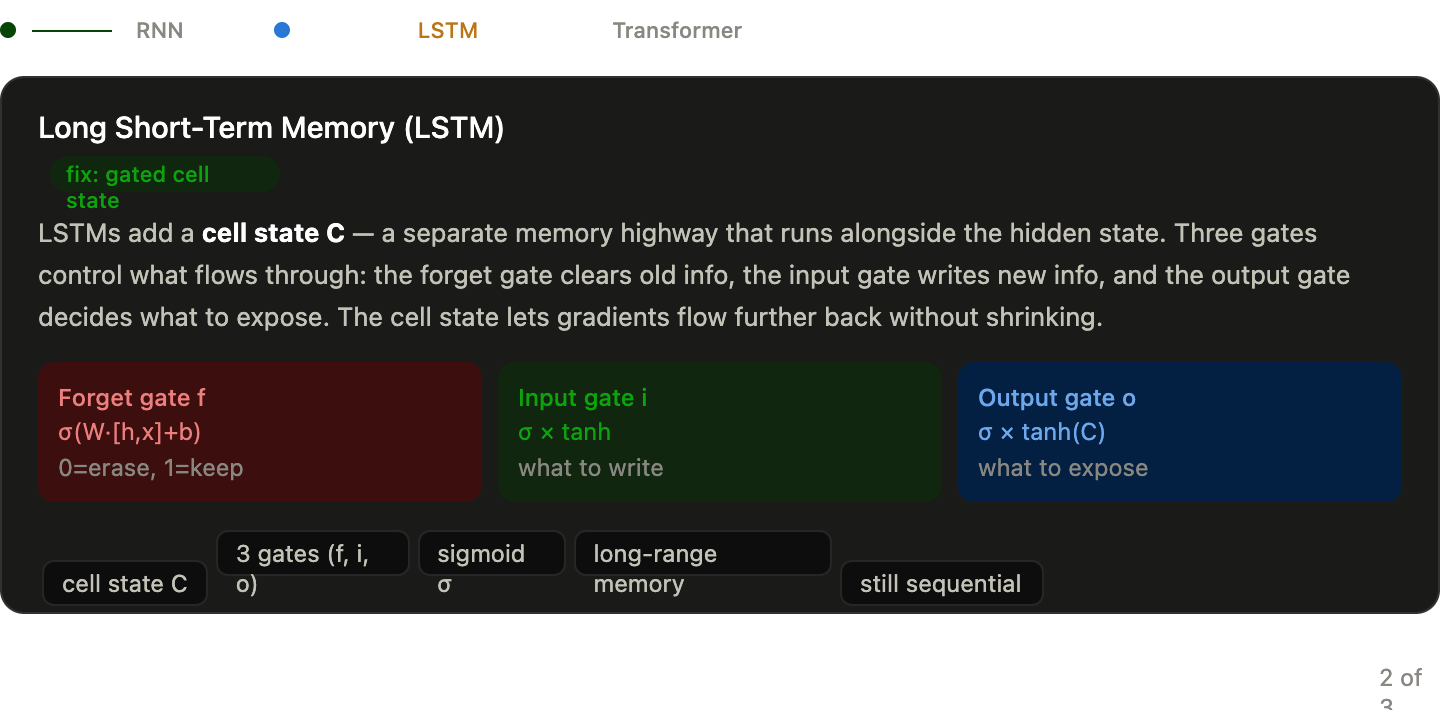

If an RNN is like writing a story on a piece of paper, erasing it, and writing the next sentence from memory, an LSTM is like having a digital document where you can specifically choose what to keep, what to delete, and what to update.1. The Superhighway: The Cell State ($C_t$)The absolute secret weapon of an LSTM is the Cell State (usually written as $C_t$).Think of it as a conveyor belt or a memory superhighway that runs straight down the entire length of the sequence.Because data can flow down this highway with only minor adjustments, information from the very first word can travel hundreds of steps without shrinking or disappearing. This completely crushes the Vanishing Gradient Problem.2. The 3 Gates (How the Highway is Controlled)To manage what goes onto and off of that conveyor belt, the LSTM uses three mathematical "valves" called gates. Every single gate uses a Sigmoid activation ($\sigma$) because it outputs a percentage between 0 (dump everything) and 1 (keep everything).1. The Forget Gate 🛑What it does: Decides what information from your past memory should be thrown away.Example: If you are reading a movie review and the text changes from talking about the acting to talking about the special effects, the forget gate lowers its value to "erase" the old acting details so they don't clutter your memory.Exam Formula: $f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$2. The Input Gate 📝What it does: Decides what new information from the current word is worth adding to the conveyor belt.How it works: It works with a sidekick $\tanh$ layer that creates a list of "candidate new memories." The Input gate acts as the filter choosing which ones actually get written down.Exam Formula: $i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$3. The Output Gate 📤What it does: Decides what the next Hidden State ($h_t$) should be. It takes the clean memory from the conveyor belt, runs it through a filter, and decides what information to actually output to the next layer or step.Exam Formula: $o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$3. The Ultimate MCQ Trap for LSTMs 🪤Professors love this question because almost everyone slips up on it: Which activation functions are used where inside an LSTM cell?The Gates (Forget, Input, Output): They strictly use Sigmoid ($\sigma$). Why? Because gates are filters, and you need a percentage between 0 and 1 to scale things.The Blocks/Calculations: The actual information content uses Tanh (values between -1 and 1) to prevent values from exploding out of control during addition operations.If an MCQ option suggests the Forget Gate uses a Tanh activation, it is a trap! It's always Sigmoid.

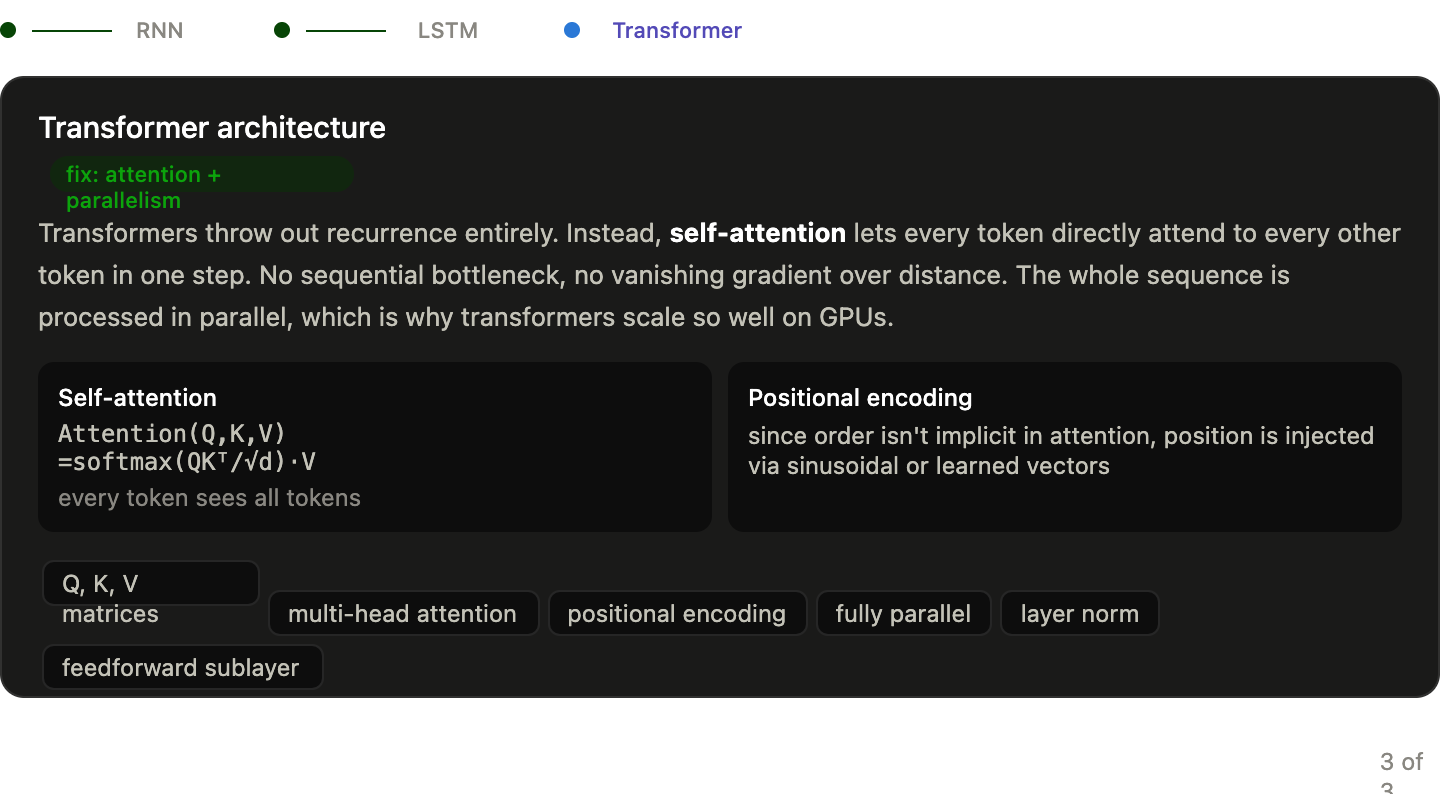

**Trap 1 — LSTM solves the vanishing gradient completely**. Not completely. LSTM dramatically reduces it via the cell state highway, but very deep stacked LSTMs still suffer. Transformers with residual connections handle it better.

**Trap 2 — the forget gate uses tanh**. No. All three gates (forget, input, output) use sigmoid σ to produce values between 0 and 1 (acting as a percentage). Only the candidate cell state uses tanh (producing values between -1 and 1 representing new information). Mixing these up is the most common LSTM MCQ trap.

**Trap 3 — RNNs can be parallelized**. No. Each timestep depends on the previous hidden state — strictly sequential. This is why LSTMs are slow on long sequences and why transformers (fully parallel) dominate at scale.

**Trap 4 — positional encoding is learned weights**. It can be either — sinusoidal (fixed formula, original "Attention is All You Need" paper) or learned (BERT uses learned positional embeddings). Both are valid; the key point is that transformers need some form of positional encoding because self-attention alone has no notion of token order.

**Trap 5 — return_sequences=True is always needed for LSTM stacking**. Only needed when the next layer also expects a sequence (i.e., another LSTM). The final LSTM before a Dense layer uses the default return_sequences=False, which returns only the last hidden state.

**Trap 6 — the feedforward layer in a transformer uses attention**. No. It is a simple two-layer MLP applied independently to each token position. Only the attention sublayer does cross-token communication. The FFN expands to 4× the model dimension then back down.

In [1]:
import numpy as np
import torch
import torch.nn as nn

In [2]:
class Rnnclassifier(nn.Module):
  def __init__(self, vocab_size=5000, embed_dim=64, hidden_dim=32):
    super().__init__()
    self.embedding=nn.Embedding(vocab_size,embed_dim)
    self.rnn=nn.RNN(embed_dim,hidden_dim,batch_first=True)
    self.fc=nn.Linear(hidden_dim,1)


  def forward(self,x):
    x=self.embedding(x)
    out,h_n=self,rnn(x)
    return torch.sigmoid(self.fc(h_n.squeeze(0)))

